In [ ]:
import numpy as np
import matplotlib.pyplot as plt
arctan = np.arctan2
pi = np.pi

In [16]:
def plot_displacement_field(X,Y,Z,z_axis_label):
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(projection='3d')

    # Create surface plot of the displacement field
    surf = ax.plot_surface(Y, X, Z, cmap='coolwarm', edgecolor='none', alpha=1, antialiased=False)



    # Rotate the angle at which the plot is displayed
    ax.view_init(elev=30, azim=160)

    # Labels and title
    ax.set_xlabel('Y', fontsize=10, fontweight='bold')
    ax.set_ylabel('X', fontsize=10, fontweight='bold')
    ax.set_zlabel(z_axis_label, labelpad=1.5, fontsize=10, fontweight='bold')
    ax.set_title(r'Displacement Field', fontsize=18, fontweight='bold')


    plt.tight_layout()
    plt.show()

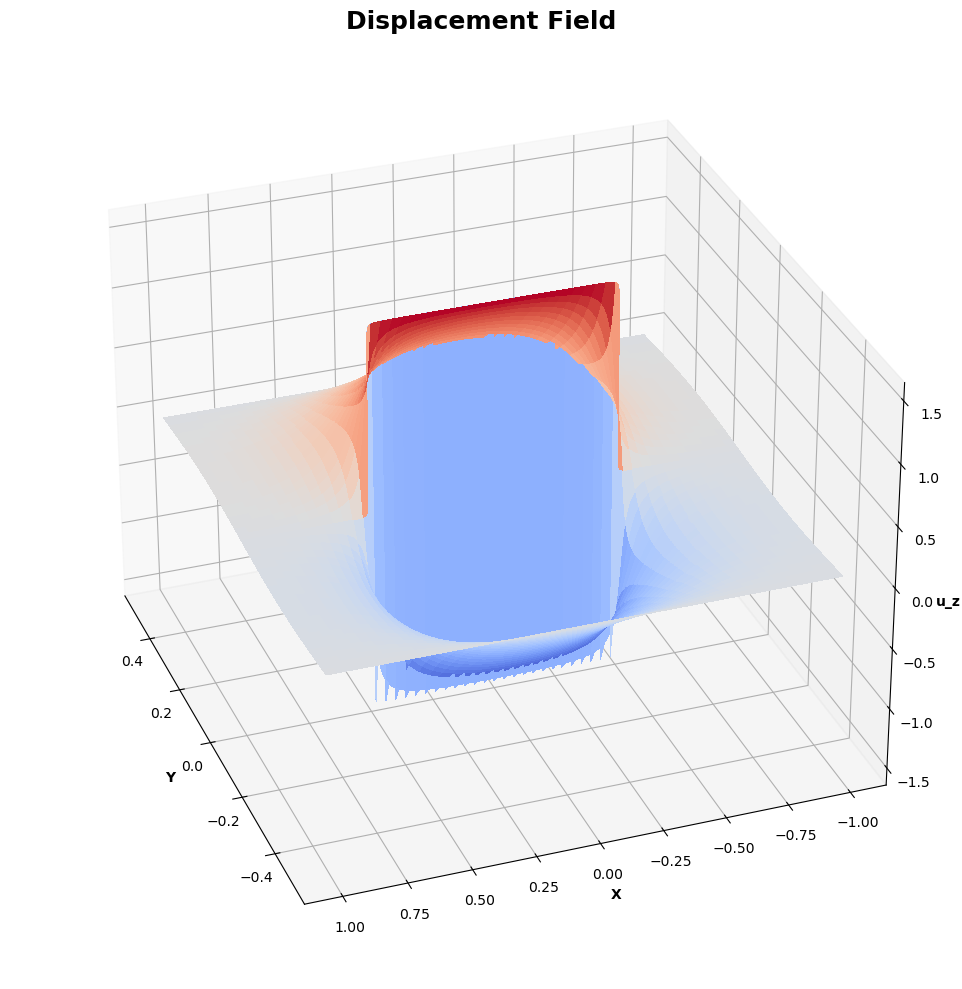

In [19]:
def u_z(x,y,b):
    theta1 = arctan(y,x-0.5)
    theta2 = arctan(y,x-(-0.5))
    frac = (theta1-theta2)/(2*pi)
    return b*frac

def u_z_image(x, y, N):
    image_sum = 0
    for i in range(-N, N+1):
        for j in range(-N, N+1):
            R = [i*2, j*1]
            x_update = x-R[0]
            y_update = y-R[1]
            image_sum += u_z(x_update,y_update,3.16)
    return image_sum

def u_z_error(x,y): 
    s_x = u_z_image(1,-0.5,10)-u_z_image(-1,-0.5,10)
    s_y = u_z_image(-1,0.5,10)-u_z_image(-1,-0.5,10)
    s = np.array([s_x, s_y])
    c_vec = np.array([(x/2)*2, y])
    err = (s[0]*c_vec[0])+(s[1]*c_vec[1])
    return err


x_values = np.linspace(-1, 1, 1000)
y_values = np.linspace(-0.5, 0.5, 1000)
X, Y = np.meshgrid(x_values, y_values)
Z = u_z_image(X,Y,10)-u_z_error(X,Y)

plot_displacement_field(X,Y,Z,"u_z")

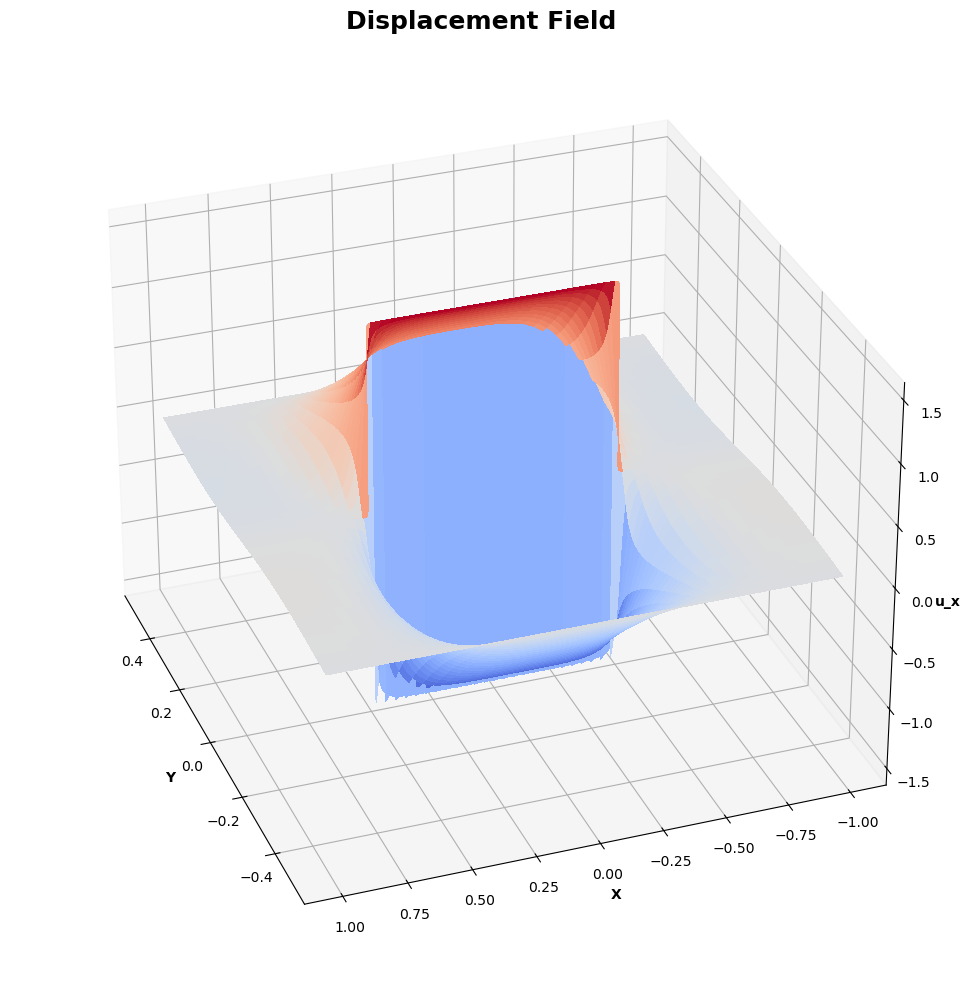

In [17]:
def u_x (x,x1, x2, y, b, v):
    factor1 = b/(2*np.pi)
    theta1 = np.arctan2(y,-(x-x1))
    term1 = ((x-x1)*(y))/(2*(1-v)*((x-x1)**2+(y)**2))
    factor2 = -b/(2*np.pi)
    theta2 = np.arctan2(y,-(x-x2))
    term2 = ((x-x2)*(y))/(2*(1-v)*((x-x2)**2+(y)**2))
    return (factor1*(theta1 + term1))+(factor2*(theta2 + term2))

def u_x_image(x, y, N):
    image_sum = 0
    for i in range(-N, N+1):
        for j in range(-N, N+1):
            R = [i*2, j*1]
            x_update = x-R[0]
            y_update = y-R[1]
            image_sum += u_x(x_update,-0.5,0.5,y_update,3.15,0.24)
    return image_sum

def u_x_error(x,y): 
    s_x = (u_x_image(1,-0.5,10)-u_x_image(-1,-0.5,10))
    s_y = (u_x_image(-1,0.5,10)-u_x_image(-1,-0.5,10))
    s = np.array([s_x, s_y]) 
    err = (s_x/2)*x + (s_y/1)*y
    #err = s_y*y
    return err



x_values = np.linspace(-1, 1, 1000)
y_values = np.linspace(-0.5, 0.5, 1000)
X, Y = np.meshgrid(x_values, y_values)
Z =   (u_x_image(X,Y,10)-u_x_error(X,Y))
plot_displacement_field(X,Y,Z,"u_x")

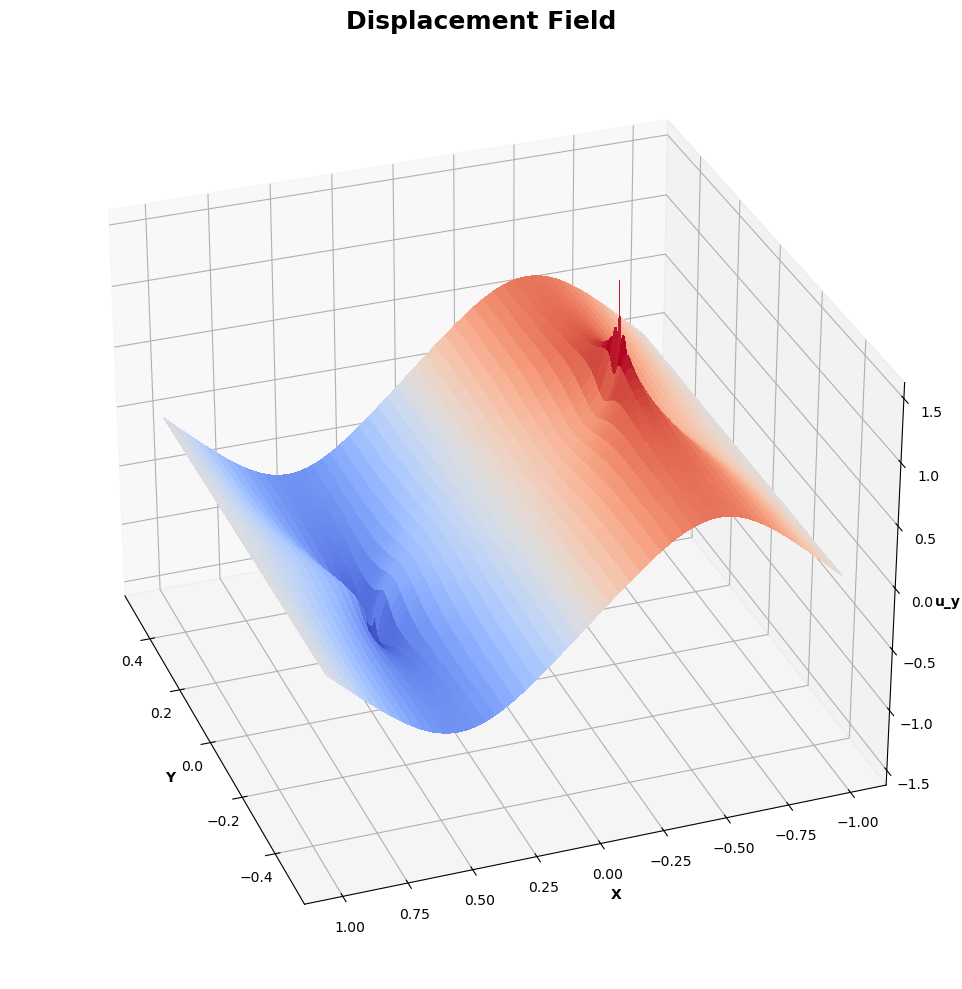

In [18]:
def u_y (x, loc1, loc2, y, b, v):
    factor1 = -b/(2*np.pi)
    term11 = ((1-2*v)/(4*(1-v)))*np.log((x-loc1)**2+y**2)
    term12 = ((x-loc1)**2-y**2)/(4*(1-v)*((x-loc1)**2+y**2))
    factor2 = b/(2*np.pi)
    term21 = ((1-2*v)/(4*(1-v)))*np.log((x-loc2)**2+y**2)
    term22 = ((x-loc2)**2-y**2)/(4*(1-v)*((x-loc2)**2+y**2))
    return (factor1*(term11+term12))+(factor2*(term21+term22))


def u_y_image(x, y, N):
    image_sum = 0
    for i in range(-N, N+1):
        for j in range(-N, N+1):
            R = [i*2, j*1]
            x_update = x-R[0]
            y_update = y-R[1]
            image_sum += u_y(x_update,-0.5,0.5,y_update,3.15,0.24)
    return image_sum

def u_y_error(x,y): 
    s_x = u_y_image(1,-0.5,10)-u_y_image(-1,-0.5,10)
    s_y = u_y_image(-1,0.5,10)-u_y_image(-1,-0.5,10)
    err = (s_x/2)*x + s_y * y
    #err = s_x*x
    return err

x_values = np.linspace(-1, 1, 1000)
y_values = np.linspace(-0.5, 0.5, 1000)
X, Y = np.meshgrid(x_values, y_values)
Z =   (u_y_image(X,Y,10)-u_y_error(X,Y))

plot_displacement_field(X,Y,Z,"u_y")